# Exercise 07: Wikipedia Vote Network

We test whether the Wikipedia admin-election vote network shows the small-world pattern: high clustering relative to a random baseline, with similarly short average paths.

In [9]:
import networkx as nx
from networkx.algorithms.community import louvain_communities
import numpy as np
import random
import matplotlib.pyplot as plt
from pathlib import Path

## Load Data

**Citation:** J. Leskovec, D. Huttenlocher, J. Kleinberg. Signed networks in social media. CHI 2010.

Edge A→B means user A voted for user B in a Wikipedia admin-promotion election.

In [10]:
data_path = Path('data/wiki-Vote.txt')
G = nx.DiGraph()

with open(data_path, 'r') as f:
    for line in f:
        line = line.strip()
        if line.startswith('#') or not line:
            continue
        parts = line.split('\t')
        if len(parts) >= 2:
            u, v = int(parts[0]), int(parts[1])
            G.add_edge(u, v)

print(f"Directed graph loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Directed graph loaded: 7115 nodes, 103689 edges


## Graph Preparation

Small-world metrics require an undirected graph. We convert by treating A→B and B→A as a single undirected edge {A, B}.

We use the Largest Connected Component (LCC). The LCC contains 7,066 of 7,115 nodes (99.3%). The remaining 49 nodes are not part of the main component.

In [11]:
G_und = G.to_undirected()
lcc_nodes = max(nx.connected_components(G_und), key=len)
G_lcc = G_und.subgraph(lcc_nodes).copy()

n = G_lcc.number_of_nodes()
m = G_lcc.number_of_edges()

## Small-World Metrics

**Clustering coefficient C**: fraction of a node's neighbours that are also connected to each other. High C means tight local circles.

**Average path length L**: mean distance between all node pairs. Exact all-pairs BFS is too slow for this graph size, so we sample 500 source nodes (seed=42). Self-distances are excluded.

In [12]:
random.seed(42)

# Clustering coefficient, exact
C_real = nx.average_clustering(G_lcc)

# Average path length, sampled (exact is too slow on 7k nodes)
SAMPLE_SIZE = 500
sample_nodes = random.sample(list(G_lcc.nodes()), SAMPLE_SIZE)

path_lengths_real = []
for src in sample_nodes:
    sp = nx.single_source_shortest_path_length(G_lcc, src)
    path_lengths_real.extend(v for v in sp.values() if v > 0)  # exclude self-distance

L_real = float(np.mean(path_lengths_real))

print(f"C = {C_real:.4f},  L = {L_real:.4f}")

C = 0.1419,  L = 3.2377


## ER Random Baseline

We generate an Erdos-Renyi graph G(n, p) with n = 7,066 and p = 2m / (n(n-1)) ≈ 0.0040, matching the LCC node count and edge density. The same C and L metrics are computed on its LCC.

In [13]:
p_er = (2 * m) / (n * (n - 1))

G_er = nx.erdos_renyi_graph(n, p_er, seed=42)
er_lcc_nodes = max(nx.connected_components(G_er), key=len)
G_er_lcc = G_er.subgraph(er_lcc_nodes).copy()

n_er = G_er_lcc.number_of_nodes()
m_er = G_er_lcc.number_of_edges()

C_er = nx.average_clustering(G_er_lcc)

sample_er = random.sample(list(G_er_lcc.nodes()), SAMPLE_SIZE)
path_lengths_er = []
for src in sample_er:
    sp = nx.single_source_shortest_path_length(G_er_lcc, src)
    path_lengths_er.extend(v for v in sp.values() if v > 0)
L_er = float(np.mean(path_lengths_er))

print(f"C = {C_er:.4f},  L = {L_er:.4f}")

C = 0.0039,  L = 2.9326


## Small-World Comparison

In [14]:
sigma   = C_real / C_er          # clustering ratio: >> 1 means much more clustered than random
L_ratio = L_real / L_er          # path-length ratio: ~ 1 means paths as short as random

print("| Metric                          | Wikipedia LCC     | ER Baseline       | Ratio              |")
print("|---------------------------------|-------------------|-------------------|--------------------|")
print(f"| Nodes in LCC                    | {n:<17} | {n_er:<17} |                    |")
print(f"| Edges in LCC                    | {m:<17} | {m_er:<17} | {m/m_er:<18.2f} |")
print(f"| Avg clustering coeff C          | {C_real:<17.4f} | {C_er:<17.4f} | sigma = {sigma:<11.1f} |")
print(f"| Avg path length L (sampled)     | {L_real:<17.4f} | {L_er:<17.4f} | {L_ratio:<18.2f} |")

| Metric                          | Wikipedia LCC     | ER Baseline       | Ratio              |
|---------------------------------|-------------------|-------------------|--------------------|
| Nodes in LCC                    | 7066              | 7066              |                    |
| Edges in LCC                    | 100736            | 100354            | 1.00               |
| Avg clustering coeff C          | 0.1419            | 0.0039            | sigma = 36.3        |
| Avg path length L (sampled)     | 3.2377            | 2.9326            | 1.10               |


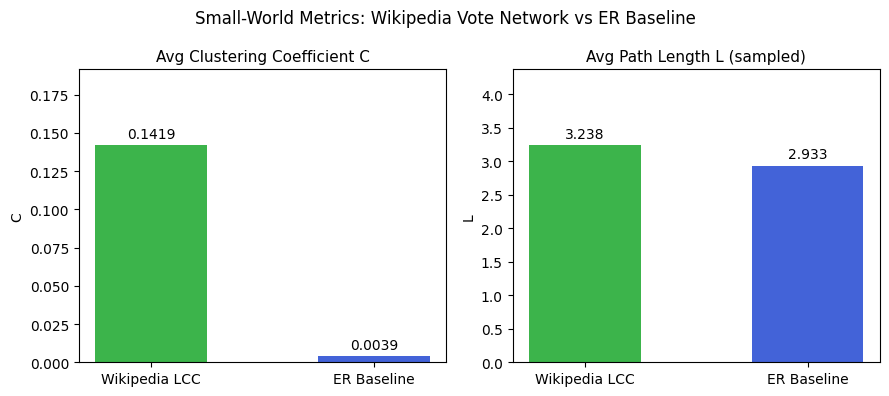

Saved: small_world_comparison.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

labels = ['Wikipedia LCC', 'ER Baseline']
colors = ['#3cb44b', '#4363d8']

# Left panel: clustering coefficient
ax = axes[0]
bars = ax.bar(labels, [C_real, C_er], color=colors, width=0.5)
ax.set_title('Avg Clustering Coefficient C', fontsize=11)
ax.set_ylabel('C')
for bar, v in zip(bars, [C_real, C_er]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(C_real, C_er) * 0.02,
            f'{v:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_ylim(0, max(C_real, C_er) * 1.35)

# Right panel: average path length
ax = axes[1]
bars = ax.bar(labels, [L_real, L_er], color=colors, width=0.5)
ax.set_title('Avg Path Length L (sampled)', fontsize=11)
ax.set_ylabel('L')
for bar, v in zip(bars, [L_real, L_er]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(L_real, L_er) * 0.02,
            f'{v:.3f}', ha='center', va='bottom', fontsize=10)
ax.set_ylim(0, max(L_real, L_er) * 1.35)

plt.suptitle('Small-World Metrics: Wikipedia Vote Network vs ER Baseline', fontsize=12)
plt.tight_layout()
plt.savefig('small_world_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: small_world_comparison.png")

## Shortcut Identification

We identify nodes that act as bridges between local regions using two measures:
approximate betweenness centrality (k=200 pivot nodes) and Louvain community membership.
Nodes with high betweenness that also span multiple communities are the structural shortcuts.

In [16]:
# Community partition (Louvain, seed=42)
louvain_comms = louvain_communities(G_lcc, seed=42)
partition = {node: cid for cid, comm in enumerate(louvain_comms) for node in comm}
num_comms = len(louvain_comms)

# Approximate betweenness centrality (k=200 pivot nodes, seed=42)
random.seed(42)
bc = nx.betweenness_centrality(G_lcc, k=200, normalized=True, seed=42)
top_bc = sorted(bc.items(), key=lambda x: -x[1])[:10]

degree_dict = dict(G_lcc.degree())

def comms_bridged(node):
    own = partition[node]
    return len({partition[nb] for nb in G_lcc.neighbors(node)} - {own})

print("| Rank | Node | Degree | Betweenness | Communities Bridged |")
print("|------|------|--------|-------------|---------------------|")
for rank, (node, bc_val) in enumerate(top_bc[:5], 1):
    print(f"| {rank:<4} | {node:<4} | {degree_dict[node]:<6} | {bc_val:.4f}      | {comms_bridged(node):<19} |")

print()
shortcut_nodes = [node for node, _ in top_bc[:2]]
for node in shortcut_nodes:
    own_comm = partition[node]
    bridged = {partition[nb] for nb in G_lcc.neighbors(node)} - {own_comm}
    print(f"Node {node}: degree={degree_dict[node]}, community={own_comm}, "
          f"bridges {len(bridged)} other communities {sorted(bridged)}")

| Rank | Node | Degree | Betweenness | Communities Bridged |
|------|------|--------|-------------|---------------------|
| 1    | 2565 | 1065   | 0.0562      | 3                   |
| 2    | 11   | 743    | 0.0356      | 3                   |
| 3    | 457  | 732    | 0.0354      | 3                   |
| 4    | 766  | 773    | 0.0302      | 3                   |
| 5    | 15   | 403    | 0.0297      | 3                   |

Node 2565: degree=1065, community=1, bridges 3 other communities [0, 3, 4]
Node 11: degree=743, community=0, bridges 3 other communities [1, 3, 4]


## Conclusion

**Verdict: small-world.**

| Metric | Wikipedia LCC | ER Baseline | Ratio |
|--------|---------------|-------------|-------|
| C      | 0.1419        | 0.0039      | 36.3x |
| L      | 3.2377        | 2.9326      | 1.10  |

**High clustering (sigma = 36.3).** The ER graph at the same density has C ≈ p ≈ 0.004. The real network is 36x more clustered, reflecting groups of editors who repeatedly vote for one another within their subject areas or election cohorts.

**Short paths (L_ratio = 1.10).** Average path length is 3.24, only 10% above the ER value of 2.93. Nodes 2565 (degree 1065) and 11 (degree 743) are the main shortcuts. Each bridges 3 of the 5 Louvain communities and carries the highest betweenness (0.056 and 0.036). These high-volume voters span multiple voting blocs, collapsing the inter-community distances.

**Qualification.** This uses the undirected projection. In the directed graph, A voting for B does not imply B votes for A, so directed path lengths are longer. The small-world result applies to the undirected co-participation structure.